In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [30]:
#Data Import
df = pd.read_csv('pima-indians-diabetes.csv')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


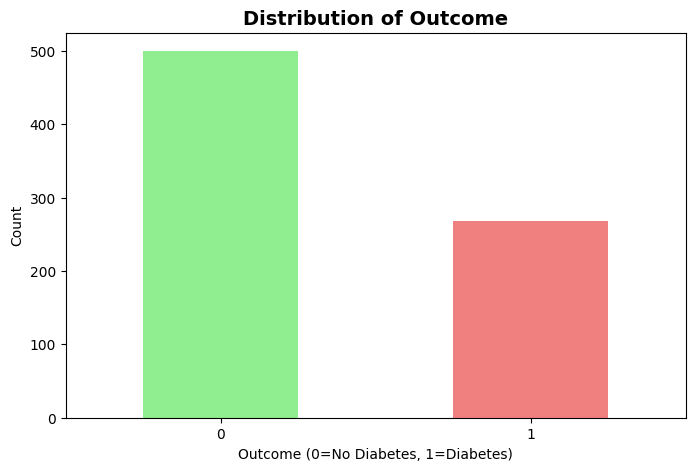

In [31]:
# Basic information
print("Dataset Info:")
print(df.info())
print("\nClass Distribution:")
print(df['Outcome'].value_counts())

# Visualize target distribution
plt.figure(figsize=(8, 5))
df['Outcome'].value_counts().plot(kind='bar', color=['lightgreen', 'lightcoral'])
plt.title('Distribution of Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [32]:

X=df.drop("Outcome",axis=1)
y=df["Outcome"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")

Training Samples: 614
Testing Samples: 154


In [33]:
#Standardize the data to improve SVM performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
#Initialize and train the SVM model
svm_model = SVC()
svm_model.fit(X_train_scaled,y_train)

#Predict on the test set
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate the model 
svm_accuracy = accuracy_score(y_test,y_pred_svm)
classification_rep_svm = classification_report(y_test,y_pred_svm)
print(f"SVM Accuracy: {svm_accuracy:.4f}")
print("Classification Report:")
print(classification_rep_svm)

SVM Accuracy: 0.7338
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.65      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



In [35]:
#Initialize and train the Gaussian Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train) # y_train is not scaled as its binary 0/1

#Predict
y_pred_nb = nb_model.predict(X_test_scaled)

#Evaluate the model
nb_accuracy = accuracy_score(y_test,y_pred_nb)
classification_rep_nb = classification_report(y_test,y_pred_nb)
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")
print("Classification Report:")
print(classification_rep_nb)



Naive Bayes Accuracy: 0.7662
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [36]:
#Initialize and train Decision tree model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_scaled,y_train)

#Predict on the test set
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate the model 
dt_accuracy = accuracy_score(y_test,y_pred_dt)
classification_rep_dt = classification_report(y_test,y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print("Classification Report:")
print(classification_rep_dt)

Decision Tree Accuracy: 0.7597
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        99
           1       0.66      0.69      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



Model Comparison
           Model  Accuracy
0            SVM  0.733766
1    Naive Bayes  0.766234
2  Decision Tree  0.759740

Best Model: Naive Bayes with Accuracy: 0.7662


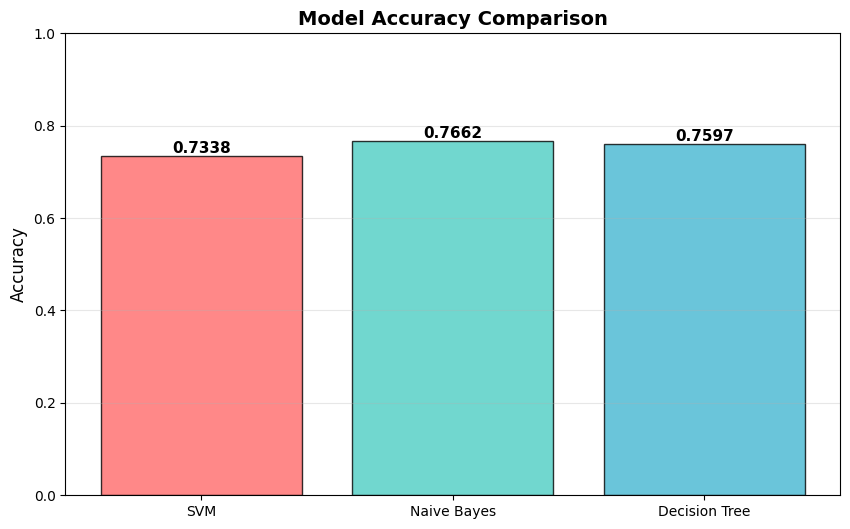

In [37]:
#Create comparative bar chart for accuracy across models
results = pd.DataFrame({
    'Model': ['SVM', 'Naive Bayes', 'Decision Tree'],
    'Accuracy': [svm_accuracy, nb_accuracy, dt_accuracy]
})

print("="*50)
print("Model Comparison")
print("="*50)
print(results)

# Find best model
best_model = results.loc[results['Accuracy'].idxmax(), 'Model']
best_accuracy = results['Accuracy'].max()
print(f"\nBest Model: {best_model} with Accuracy: {best_accuracy:.4f}")

# Bar plot of accuracies
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(results['Model'], results['Accuracy'], color=colors, alpha=0.8, edgecolor='black')

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

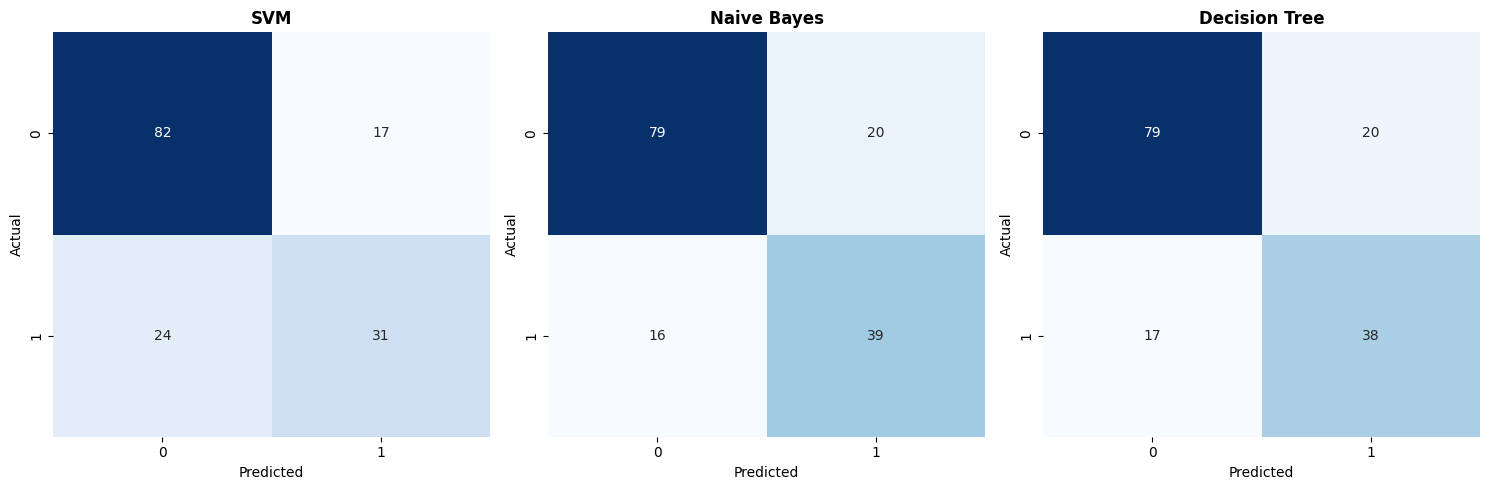

In [38]:
# Plot confusion matrix to compare predictions for each model
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_data = [
    ('SVM', y_pred_svm),
    ('Naive Bayes', y_pred_nb),
    ('Decision Tree', y_pred_dt)
]

for idx, (name, y_pred) in enumerate(models_data):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar=False)
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()